In [1]:
from training_setup.setup import setup_model_and_filename
from flow_IO import load_params

LOADING NUM STATES FAILED
Could not load num_states


In [2]:
kwargs = {
    "model": "CNF",
    "layer_size": 20,
    "network_layers": 3,
    "positive_scale": "True",
    "network": "FFJORDNet",
    "activation": "SINE",
    "num_encodings": 0,
    "rescale": "False",
    "ensemble_number": 1,
    "step_controller": "Adaptive",
    "step_size": 0.1,
    "learning_rate": 4e-3,
    "decay": "False",
    "epochs": 500,
    "plot_epochs": 10,
    "plot_intermediate": "True",
    "batches": 1,
    "num_samples": 10000,
    "resample": "True",
    "validation": "True",
    "losses": ["default"],
    "representation": "Q",
    "symmetric": "True",
    "split_training": "False",
    "problem": "10",
}

In [3]:
kwargs2 = kwargs.copy()
kwargs2["decay"] = "True"
kwargs2["epochs"] = 1000
kwargs2["step_controller"] = "Constant"
kwargs2["problem"] = "GKP"
kwargs2["losses"] = ["L1_target"]
kwargs2["network_layers"] = 5

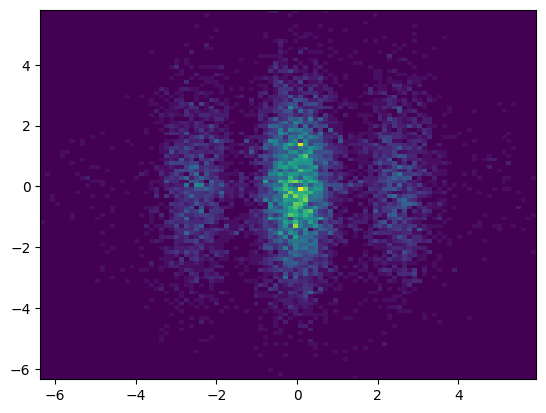

RESCALE = 1
False
0.1
THERE WAS AN ERROR, NOT USING scan stages
adaptive = False
THERE WAS AN ERROR, NOT USING COMPILE STEPS
THERE WAS AN ERROR, NOT USING scan stages
adaptive = False
THERE WAS AN ERROR, NOT USING COMPILE STEPS
CNF_GKP_FFJORD_SINE_Step=0.1_network_layers=5_epochs=1000_cosine_decay


In [4]:
model, model_params, target, target_params, filename = setup_model_and_filename(kwargs2)

In [5]:
trained_params = load_params(f"flow_params/{'Q' if kwargs['representation'] == 'Q' else 'Wigner'}/{filename}.flow")

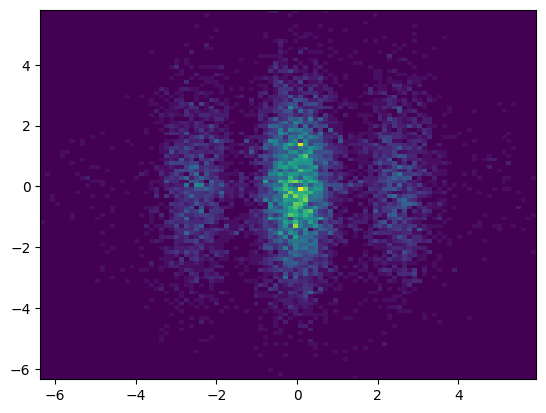

RESCALE = 1
True
0.1
THERE WAS AN ERROR, NOT USING scan stages
adaptive = True
THERE WAS AN ERROR, NOT USING scan stages
adaptive = True
CNF_GKP_FFJORD_SINE_Adaptive_network_layers=5_epochs=1000_cosine_decay


In [25]:
kwargs2 = kwargs.copy()
kwargs2["decay"] = "True"
kwargs2["epochs"] = 1000
kwargs2["step_controller"] = "Adaptive"
kwargs2["problem"] = "GKP"
kwargs2["losses"] = ["L1_target"]
kwargs2["network_layers"] = 5
model2, model_params2, target, target_params, filename = setup_model_and_filename(kwargs2)

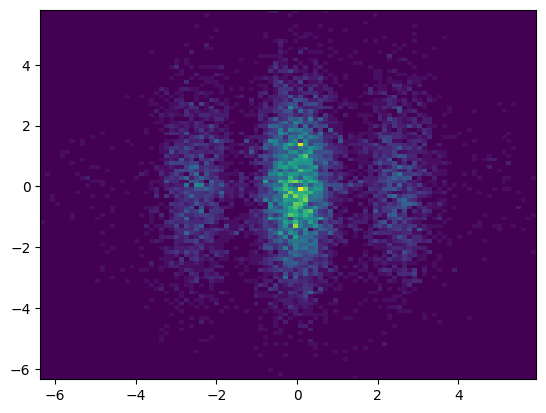

RESCALE = 1
False
0.01
THERE WAS AN ERROR, NOT USING scan stages
adaptive = False
THERE WAS AN ERROR, NOT USING COMPILE STEPS
THERE WAS AN ERROR, NOT USING scan stages
adaptive = False
THERE WAS AN ERROR, NOT USING COMPILE STEPS
CNF_GKP_FFJORD_SINE_Step=0.01_network_layers=5_epochs=1000_cosine_decay


In [7]:
kwargs2 = kwargs.copy()
kwargs2["decay"] = "True"
kwargs2["epochs"] = 1000
kwargs2["step_controller"] = "Constant"
kwargs2["step_size"] = 0.01
kwargs2["problem"] = "GKP"
kwargs2["losses"] = ["L1_target"]
kwargs2["network_layers"] = 5
model3, model_params2, target, target_params, filename = setup_model_and_filename(kwargs2)

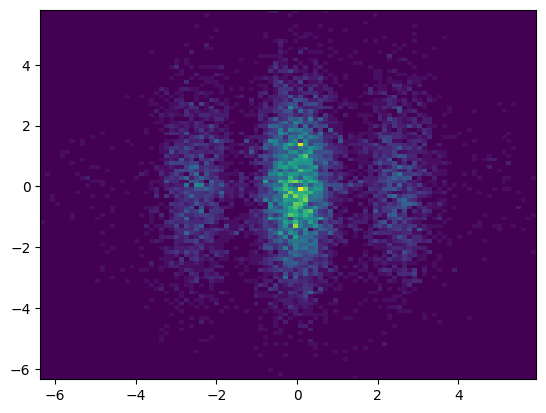

RESCALE = 1
False
0.001
THERE WAS AN ERROR, NOT USING scan stages
adaptive = False
THERE WAS AN ERROR, NOT USING COMPILE STEPS
THERE WAS AN ERROR, NOT USING scan stages
adaptive = False
THERE WAS AN ERROR, NOT USING COMPILE STEPS
CNF_GKP_FFJORD_SINE_Step=0.001_network_layers=5_epochs=1000_cosine_decay


In [8]:
kwargs2 = kwargs.copy()
kwargs2["decay"] = "True"
kwargs2["epochs"] = 1000
kwargs2["step_controller"] = "Constant"
kwargs2["step_size"] = 0.001
kwargs2["problem"] = "GKP"
kwargs2["losses"] = ["L1_target"]
kwargs2["network_layers"] = 5
model4, model_params2, target, target_params, filename = setup_model_and_filename(kwargs2)

Predicted total prob: 0.9915701640635586


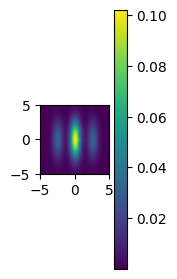

Predicted total prob: 0.9961490400725648


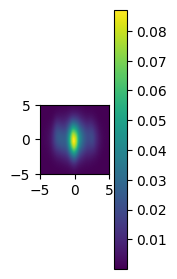

Predicted total prob: 0.9962294465407994


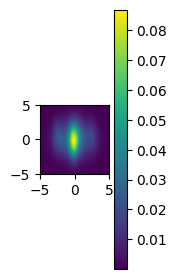

Predicted total prob: 0.9962289955338763


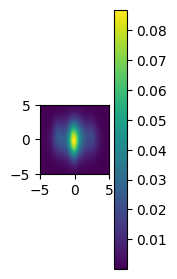

In [9]:
model.plot(trained_params, ((-5,5,0.1),(-5,5,0.1)))
model2.plot(trained_params, ((-5,5,0.1),(-5,5,0.1)))
model3.plot(trained_params, ((-5,5,0.1),(-5,5,0.1)))
model4.plot(trained_params, ((-5,5,0.1),(-5,5,0.1)))

In [29]:
import haiku as hk
import diffrax
from diffrax import RecursiveCheckpointAdjoint,BacksolveAdjoint
import jax.numpy as jnp
from matplotlib import pyplot as plt

from Q_flows.flow_util import FFJORDNet, sine

def plot_field(params, kwargs, start_points, num_steps = 100):
    field_init, apply = hk.without_apply_rng(
        hk.transform(
            lambda t, x: FFJORDNet(
                [kwargs["layer_size"]]*(kwargs["network_layers"]-1)+[2],
                activation = sine,
                random_init = True,
                positional_embeddings = 0,
            )(t, x)
        )
    )

    adjoint = RecursiveCheckpointAdjoint()

    def vector_field(t, y, params):
        return apply(params,jnp.expand_dims(t,axis=0),y)

    try:
        solver = diffrax.Tsit5(scan_stages=True)
    except:
        solver = diffrax.Tsit5()
        print("THERE WAS AN ERROR, NOT USING scan stages")

    if kwargs["step_controller"] == "Adaptive":
        print("using adaptive step controller")
        step_controller = diffrax.PIDController(rtol = 1e-2, atol = 1e-2)
    else:
        print("using constant step controller")
        try:
            step_controller = diffrax.ConstantStepSize(compile_steps = True)
        except:
            print("THERE WAS AN ERROR, NOT USING COMPILE STEPS")
            step_controller = diffrax.ConstantStepSize()

    term = diffrax.ODETerm(vector_field)

    sol = diffrax.diffeqsolve(
        term, solver, 
        0, 0.5, 0.5/num_steps, 
        y0=start_points,
        args = params[1], 
        adjoint = adjoint,
        stepsize_controller = step_controller,
        saveat = diffrax.SaveAt(t0 = True, t1 = True, ts = jnp.arange(0,0.5,0.01)),
    )
    print(sol.stats)
    print(sol.ys.shape)
    for i in range(sol.ys.shape[1]):
        plt.plot(sol.ys[:,i,0],sol.ys[:,i,1])

    plt.show()

    print(sol.stats)

    plt.scatter(sol.ys[50,:,0],sol.ys[50,:,1], alpha=0.1)
    plt.show()
    
    for i in range(0,50,10):
        plt.hist2d(sol.ys[i,:,0],sol.ys[i,:,1], bins = 100)
        plt.show()

THERE WAS AN ERROR, NOT USING scan stages
using adaptive step controller
{'max_steps': 4096, 'num_accepted_steps': Array(4, dtype=int64, weak_type=True), 'num_rejected_steps': Array(0, dtype=int64, weak_type=True), 'num_steps': Array(4, dtype=int64, weak_type=True)}
(52, 400, 2)


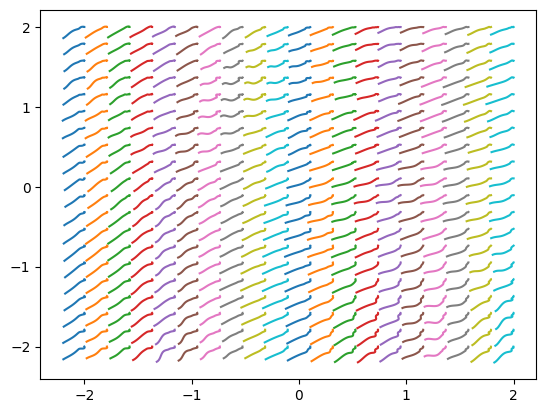

{'max_steps': 4096, 'num_accepted_steps': Array(4, dtype=int64, weak_type=True), 'num_rejected_steps': Array(0, dtype=int64, weak_type=True), 'num_steps': Array(4, dtype=int64, weak_type=True)}


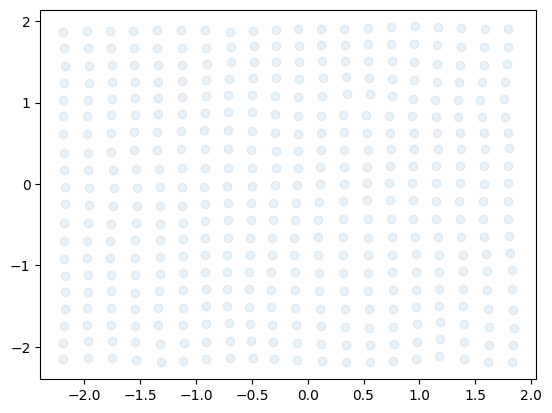

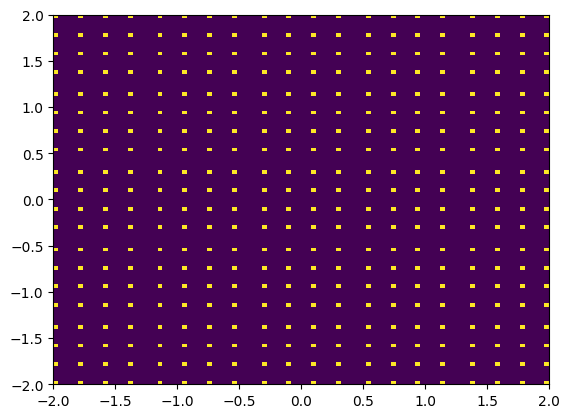

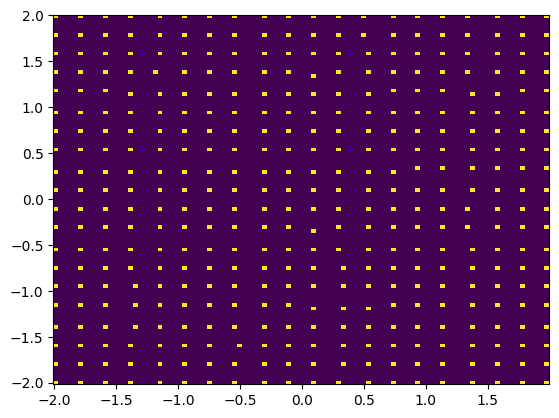

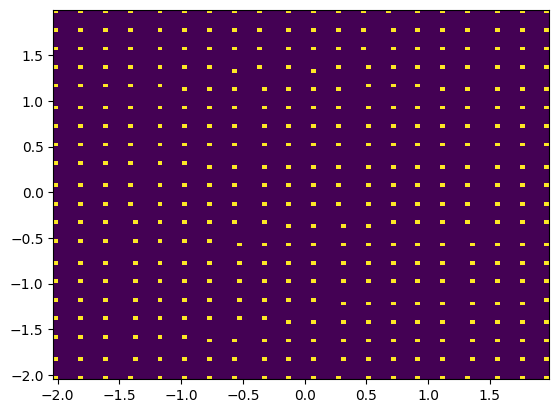

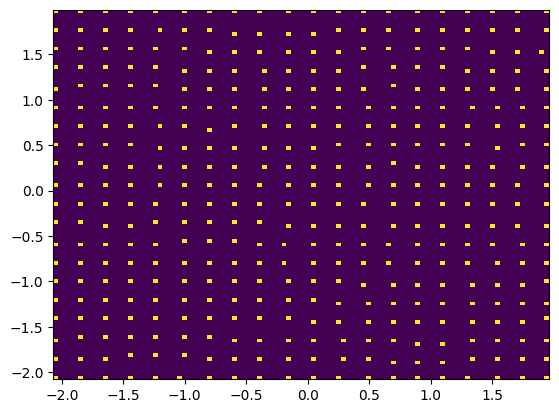

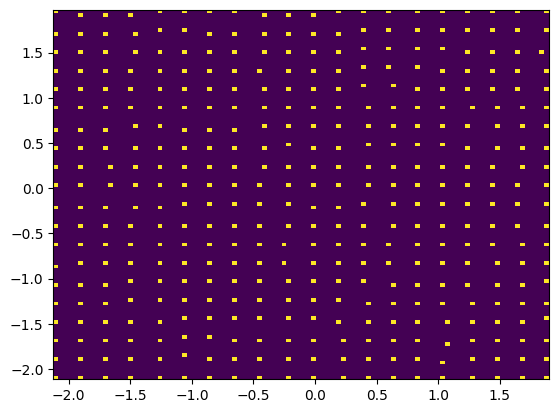

In [32]:
import jax


x = jnp.linspace(-2,2,20)
y = jnp.linspace(-2,2,20)
X,Y = jnp.meshgrid(x,y)
start_points = jnp.stack((X.flatten(),Y.flatten()),axis=1)
#start_points = jax.random.normal(jax.random.PRNGKey(0),(10000,2))
#start_points = jnp.array([[-0.5,0],[0,0],[0.5,0]])
#plot_field(trained_params, kwargs2, start_points, num_steps=5)
#plot_field(trained_params, kwargs2, start_points, num_steps=10)
#plot_field(trained_params, kwargs2, start_points, num_steps=20)
plot_field(model_params, kwargs2, start_points, num_steps=50)

THERE WAS AN ERROR, NOT USING scan stages
using adaptive step controller
{'max_steps': 4096, 'num_accepted_steps': Array(6, dtype=int64, weak_type=True), 'num_rejected_steps': Array(0, dtype=int64, weak_type=True), 'num_steps': Array(6, dtype=int64, weak_type=True)}
(52, 400, 2)


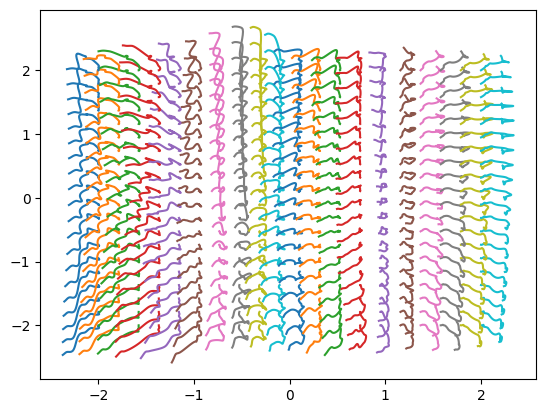

{'max_steps': 4096, 'num_accepted_steps': Array(6, dtype=int64, weak_type=True), 'num_rejected_steps': Array(0, dtype=int64, weak_type=True), 'num_steps': Array(6, dtype=int64, weak_type=True)}


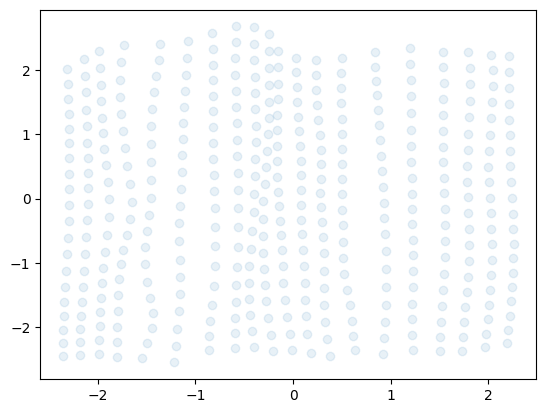

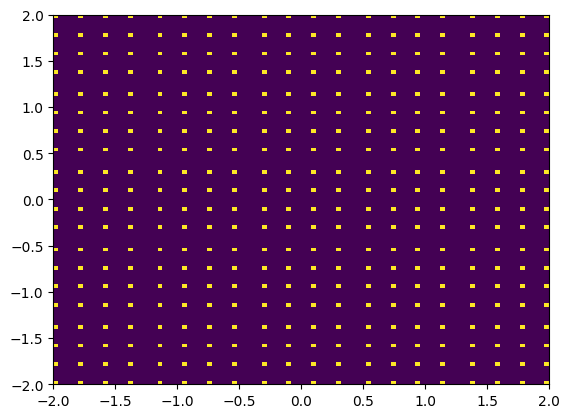

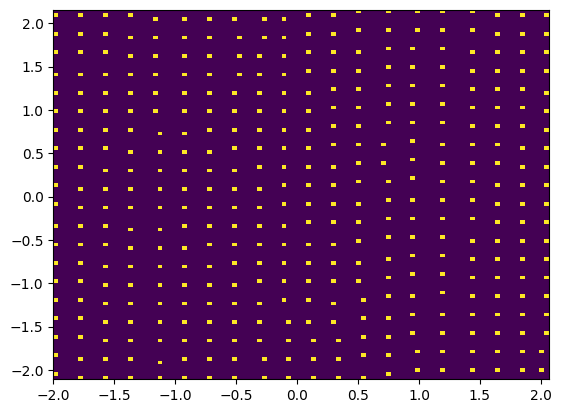

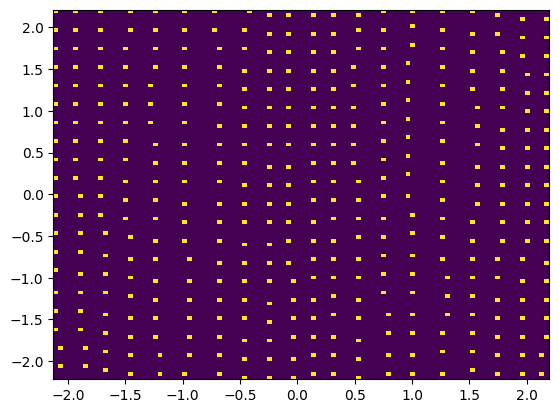

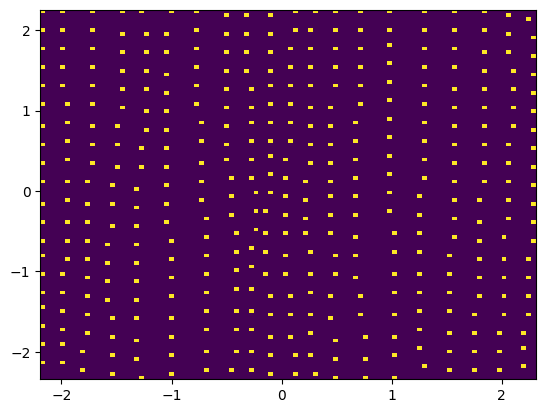

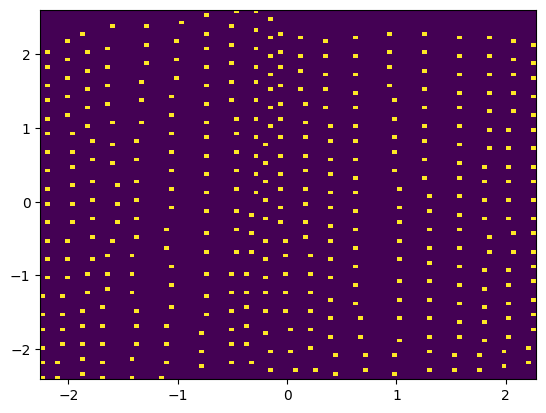

In [31]:
import jax


x = jnp.linspace(-2,2,20)
y = jnp.linspace(-2,2,20)
X,Y = jnp.meshgrid(x,y)
start_points = jnp.stack((X.flatten(),Y.flatten()),axis=1)
#start_points = jax.random.normal(jax.random.PRNGKey(0),(10000,2))
#start_points = jnp.array([[-0.5,0],[0,0],[0.5,0]])
#plot_field(trained_params, kwargs2, start_points, num_steps=5)
#plot_field(trained_params, kwargs2, start_points, num_steps=10)
#plot_field(trained_params, kwargs2, start_points, num_steps=20)
plot_field(trained_params, kwargs2, start_points, num_steps=50)

THERE WAS AN ERROR, NOT USING scan stages
using constant step controller
THERE WAS AN ERROR, NOT USING COMPILE STEPS
{'max_steps': 4096, 'num_accepted_steps': Array(5, dtype=int64, weak_type=True), 'num_rejected_steps': Array(0, dtype=int64, weak_type=True), 'num_steps': Array(5, dtype=int64, weak_type=True)}
(52, 10000, 2)


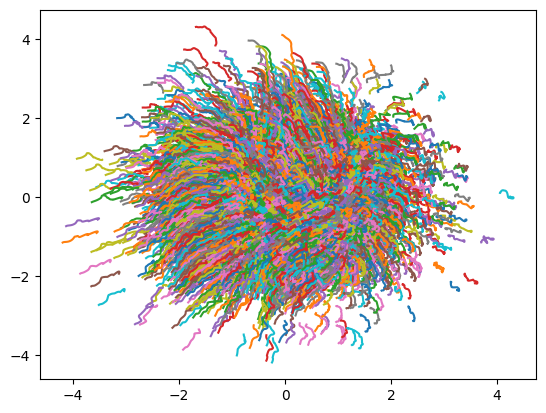

{'max_steps': 4096, 'num_accepted_steps': Array(5, dtype=int64, weak_type=True), 'num_rejected_steps': Array(0, dtype=int64, weak_type=True), 'num_steps': Array(5, dtype=int64, weak_type=True)}


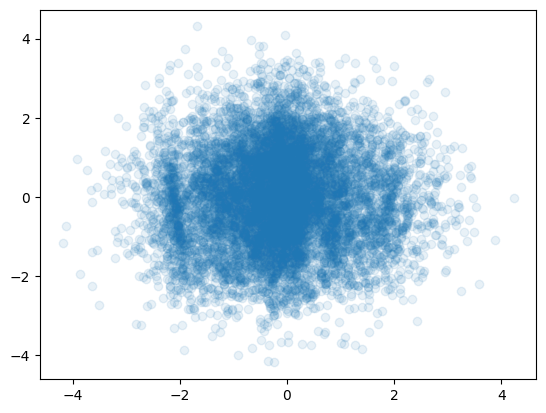

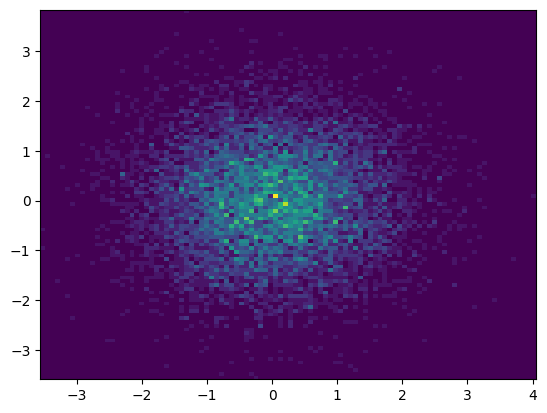

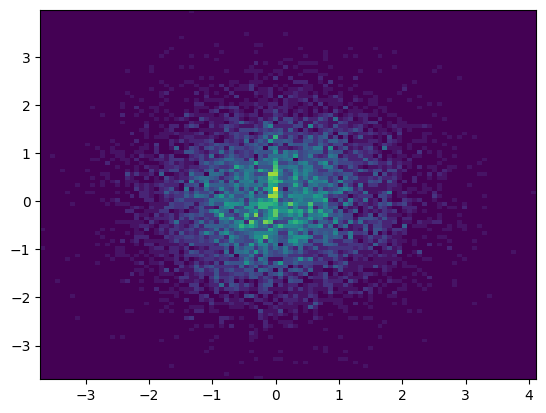

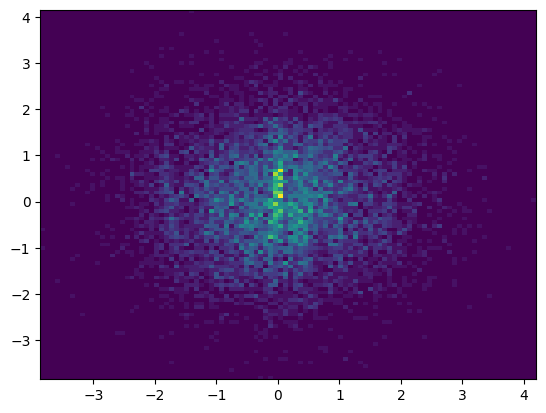

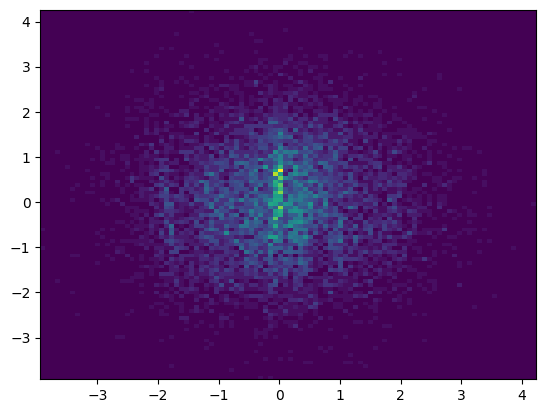

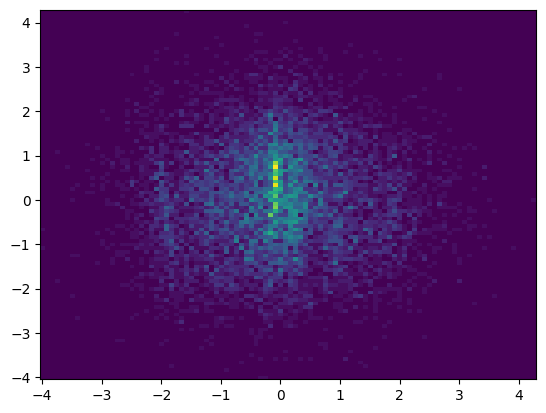

In [17]:
plot_field(trained_params, kwargs2, start_points, num_steps=5)

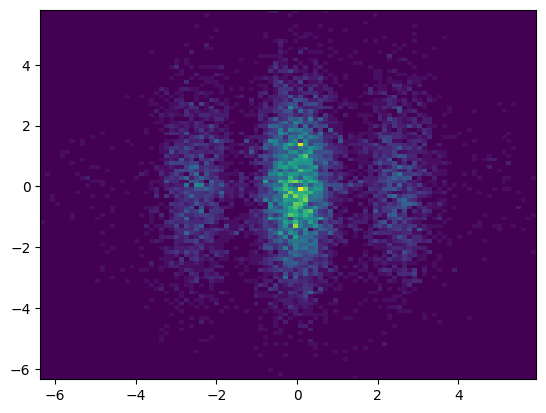

RESCALE = 1
True
0.001
THERE WAS AN ERROR, NOT USING scan stages
adaptive = True
THERE WAS AN ERROR, NOT USING scan stages
adaptive = True
CNF_GKP_FFJORD_SINE_Adaptive_network_layers=5_L1_model_control_epochs=1000_cosine_decay


In [20]:
kwargs3 = kwargs.copy()
kwargs3["decay"] = "True"
kwargs3["epochs"] = 1000
kwargs3["step_controller"] = "Adaptive"
kwargs3["step_size"] = 0.001
kwargs3["problem"] = "GKP"
kwargs3["losses"] = ["L1_model_control"]
kwargs3["network_layers"] = 5
model4, model_params2, target, target_params, filename = setup_model_and_filename(kwargs3)

In [21]:
trained_params2 = load_params(f"flow_params/{'Q' if kwargs['representation'] == 'Q' else 'Wigner'}/{filename}.flow")

THERE WAS AN ERROR, NOT USING scan stages
using constant step controller
THERE WAS AN ERROR, NOT USING COMPILE STEPS
{'max_steps': 4096, 'num_accepted_steps': Array(5, dtype=int64, weak_type=True), 'num_rejected_steps': Array(0, dtype=int64, weak_type=True), 'num_steps': Array(5, dtype=int64, weak_type=True)}
(52, 10000, 2)


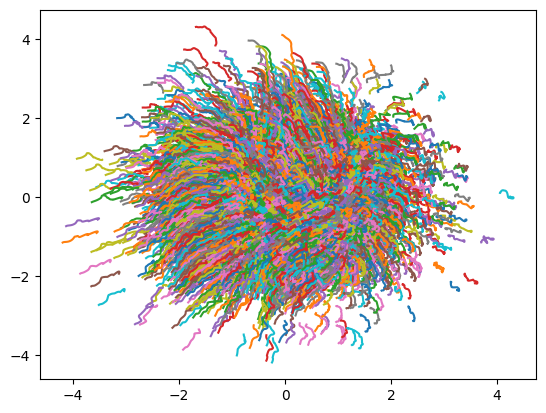

{'max_steps': 4096, 'num_accepted_steps': Array(5, dtype=int64, weak_type=True), 'num_rejected_steps': Array(0, dtype=int64, weak_type=True), 'num_steps': Array(5, dtype=int64, weak_type=True)}


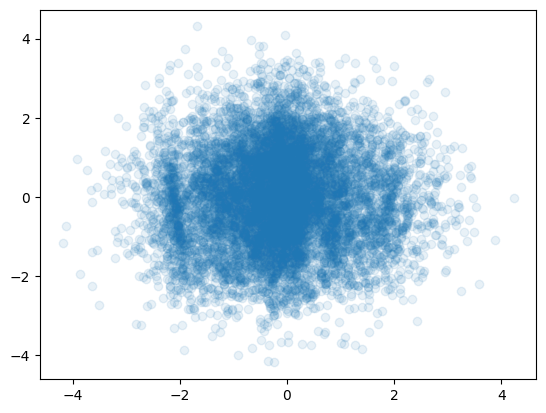

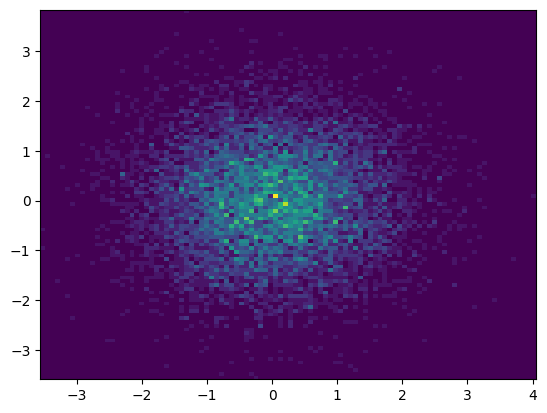

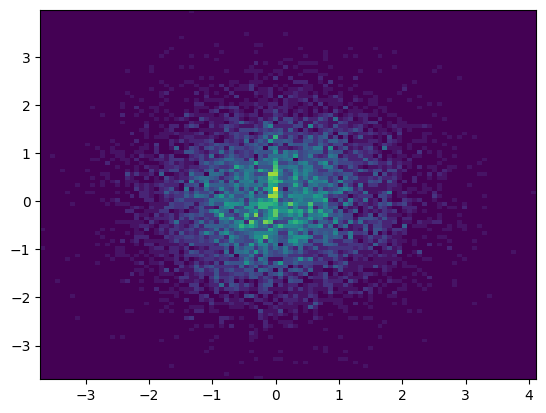

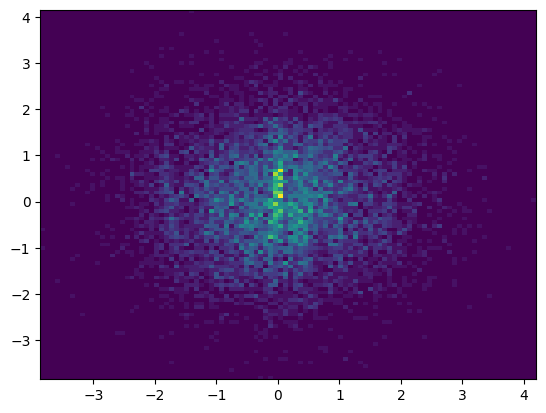

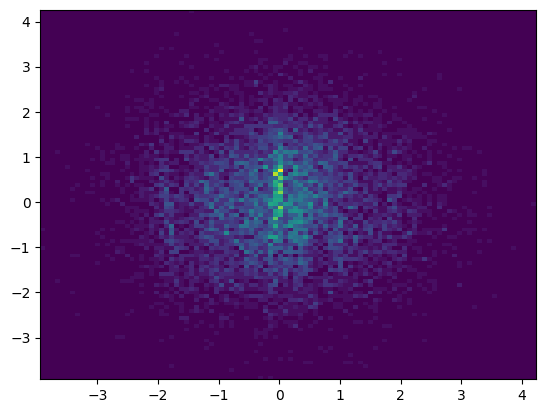

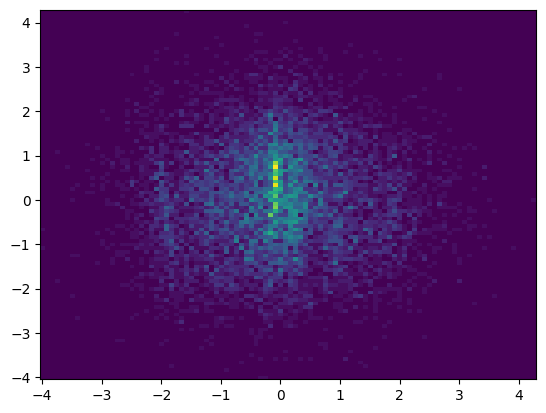

In [22]:
plot_field(trained_params, kwargs2, start_points, num_steps=5)